# Notebook 03 - Vision Transformer From Scratch

VisionNarrator | Stage 3

---

## 1. Objective

Build ViT completely from scratch.

Preprocessed image
      ↓
Patches + Embeddings
      ↓
Transformer Encoder
      ↓
Image Embedding


## 2. Configuration

IMG_SIZE = 128
PATCH_SIZE = 16
EMBED_DIM = 256
DEPTH = 6
NUM_HEADS = 8
MLP_RATIO = 4.0
DROPOUT = 0.1


In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torchvision import transforms as T

In [2]:
IMG_SIZE = 128
PATCH_SIZE = 16
EMBED_DIM = 256
DEPTH = 6
NUM_HEADS = 8
MLP_RATIO = 4.0
DROPOUT = 0.1
RANDOM_SEED = 42

In [3]:
NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2
PATCH_DIM = 3 * PATCH_SIZE * PATCH_SIZE

In [5]:
torch.manual_seed(RANDOM_SEED)

In [6]:
print(f"IMG_SIZE={IMG_SIZE}")
print(f"PATCH_SIZE={PATCH_SIZE}")
print(f"EMBED_DIM={EMBED_DIM}")
print(f"DEPTH={DEPTH}")
print(f"NUM_HEADS={NUM_HEADS}")
print(f"MLP_RATIO={MLP_RATIO}")
print(f"DROPOUT={DROPOUT}")
print(f"NUM_PATCHES={NUM_PATCHES}")
print(f"PATCH_DIM={PATCH_DIM}")


IMG_SIZE=128
PATCH_SIZE=16
EMBED_DIM=256
DEPTH=6
NUM_HEADS=8
MLP_RATIO=4.0
DROPOUT=0.1
NUM_PATCHES=64
PATCH_DIM=768


## 3. Load One Preprocessed Image

train.csv
    ↓
PIL Image
    ↓
Resize + ToTensor + Normalize
    ↓
(3, 128, 128)


In [7]:
def resolve_base_dir() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "src" / "data").exists():
        return cwd
    if (cwd.parent / "src" / "data").exists():
        return cwd.parent
    return cwd

In [8]:
BASE_DIR = resolve_base_dir()
DATA_DIR = BASE_DIR / "src" / "data"
TRAIN_CSV = DATA_DIR / "train.csv"

In [ ]:
train_df = pd.read_csv(TRAIN_CSV)

In [10]:
base_transform = T.Compose(
    [
        T.Resize((IMG_SIZE, IMG_SIZE)),
        T.ToTensor(),
        T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    ]
)

In [11]:
sample_row = train_df.iloc[0]
sample_pil = Image.open(sample_row["image_path"]).convert("RGB")
sample = base_transform(sample_pil)

In [12]:
print(f"Image: {sample_row['image']}")
print(f"Caption: {sample_row['caption']}")
print(f"Tensor shape: {tuple(sample.shape)}")
print(f"Pixel range: ({sample.min().item():.3f}, {sample.max().item():.3f})")


Image: 1000092795.jpg
Caption: Two young guys with shaggy hair look at their hands while hanging out in the yard .
Tensor shape: (3, 128, 128)
Pixel range: (-0.976, 1.000)


## 4. Patch Extraction Concept

128×128
    ↓
64 patches
    ↓
16×16×3
    ↓
768

The image is cut into a grid of 8×8 = 64 non-overlapping patches. Each patch covers 16×16 pixels across 3 channels, which flattens into a 768-dim vector. The transformer treats these 64 vectors as a sequence of tokens.

`unfold` slices the tensor along height and width, `permute` reorders the axes so each patch is a contiguous unit, and `view` flattens every patch into one row.


In [13]:
def extract_patches(img_tensor, patch_size=PATCH_SIZE):
    C, H, W = img_tensor.shape
    assert H % patch_size == 0 and W % patch_size == 0, "Image size must be divisible by patch size"
    patches = img_tensor.unfold(1, patch_size, patch_size).unfold(2, patch_size, patch_size)
    patches = patches.permute(1, 2, 0, 3, 4)
    patches = patches.contiguous().view(-1, C * patch_size * patch_size)
    return patches

patches = extract_patches(sample)

print(f"Input shape: {tuple(sample.shape)}")
print(f"Patches shape: {tuple(patches.shape)}")


Input shape: (3, 128, 128)
Patches shape: (64, 768)


## 5. Patch Visualization

Original
+
Patch grid


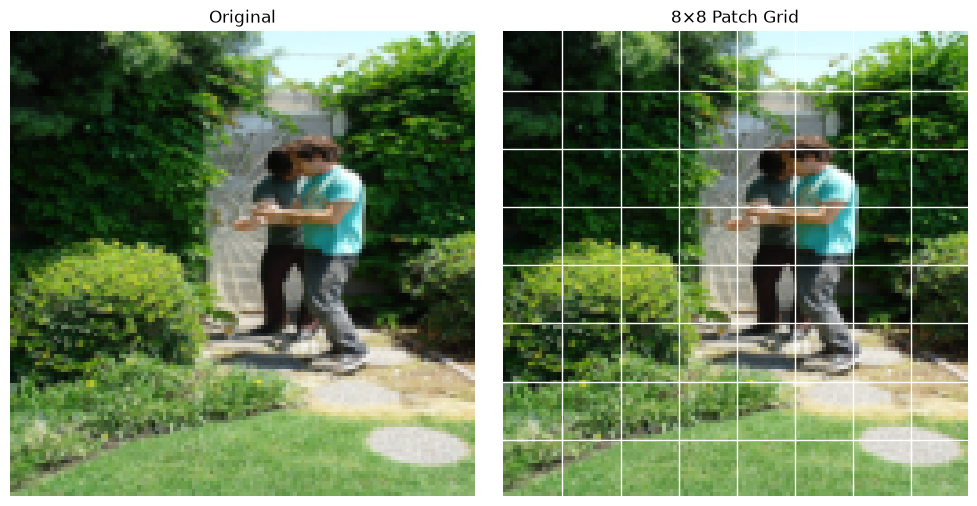

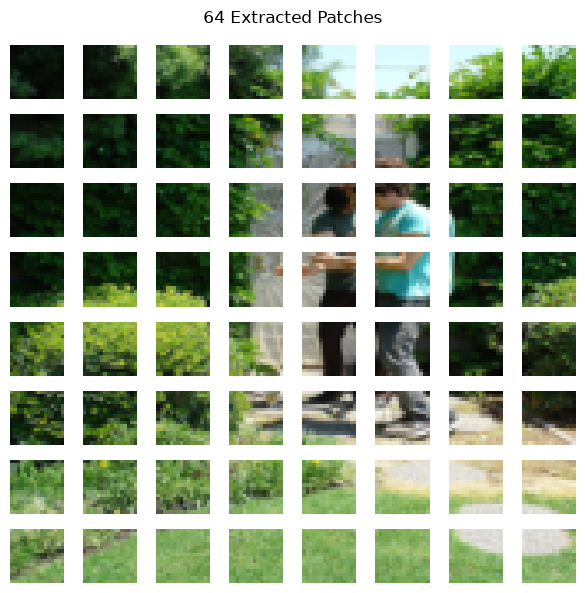

In [14]:
def denormalize_image(image_tensor: torch.Tensor) -> torch.Tensor:
    image = image_tensor.detach().cpu().clone()
    image = image * 0.5 + 0.5
    return image.clamp(0, 1)

grid_size = IMG_SIZE // PATCH_SIZE

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(denormalize_image(sample).permute(1, 2, 0))
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(denormalize_image(sample).permute(1, 2, 0))
for i in range(1, grid_size):
    axes[1].axhline(i * PATCH_SIZE, color="white", linewidth=1)
    axes[1].axvline(i * PATCH_SIZE, color="white", linewidth=1)
axes[1].set_title(f"{grid_size}×{grid_size} Patch Grid")
axes[1].axis("off")

plt.tight_layout()
plt.show()

patch_images = patches.view(-1, 3, PATCH_SIZE, PATCH_SIZE)
fig, axes = plt.subplots(grid_size, grid_size, figsize=(6, 6))
for idx, ax in enumerate(axes.flatten()):
    ax.imshow(denormalize_image(patch_images[idx]).permute(1, 2, 0))
    ax.axis("off")
plt.suptitle("64 Extracted Patches")
plt.tight_layout()
plt.show()


## 6. PatchEmbedding

unfold → flatten → Linear(768 → 256)

(B, 3, 128, 128) → (B, 64, 256)

One nn.Module that extracts all patches from a batch of images and projects each 768-dim patch vector into a 256-dim embedding.


In [15]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=128, patch_size=16, in_chans=3, embed_dim=256):
        super().__init__()

        assert img_size % patch_size == 0, "img_size must be divisible by patch_size"
        self.img_size = img_size
        self.patch_size = patch_size
        self.in_chans = in_chans
        self.embed_dim = embed_dim

        self.num_patches_h = img_size // patch_size
        self.num_patches_w = img_size // patch_size
        self.num_patches = self.num_patches_h * self.num_patches_w

        self.patch_dim = in_chans * patch_size * patch_size

        self.proj = nn.Linear(self.patch_dim, embed_dim)

    def forward(self, x):
        B, C, H, W = x.shape

        assert H == self.img_size and W == self.img_size, \
            f"Expected image size {(self.img_size, self.img_size)}, got {(H, W)}"

        patches = x.unfold(2, self.patch_size, self.patch_size).unfold(3, self.patch_size, self.patch_size)
        patches = patches.permute(0, 2, 3, 1, 4, 5).contiguous()
        patches = patches.view(B, self.num_patches, self.patch_dim)

        x = self.proj(patches)

        return x

patch_embed_layer = PatchEmbedding(
    img_size=IMG_SIZE,
    patch_size=PATCH_SIZE,
    in_chans=3,
    embed_dim=EMBED_DIM,
)

tokens = patch_embed_layer(sample.unsqueeze(0))

print(f"Input shape: {tuple(sample.unsqueeze(0).shape)}")
print(f"Patch tokens shape: {tuple(tokens.shape)}")


Input shape: (1, 3, 128, 128)
Patch tokens shape: (1, 64, 256)


## 7. CLS Token

A learnable (1, 1, 256) parameter prepended to the patch sequence. It is updated by gradient descent, attends to every patch inside the encoder, and its final state becomes the whole-image embedding.

(B, 64, 256) → (B, 65, 256)


In [16]:
B, N, D = tokens.shape

cls_token = nn.Parameter(torch.zeros(1, 1, D))
nn.init.trunc_normal_(cls_token, std=0.02)

cls_tokens = cls_token.expand(B, -1, -1)
x = torch.cat([cls_tokens, tokens], dim=1)

print(f"CLS token shape: {tuple(cls_token.shape)}")
print(f"Tokens with CLS: {tuple(x.shape)}")


CLS token shape: (1, 1, 256)
Tokens with CLS: (1, 65, 256)


## 8. Positional Embedding

Patches carry no order information, so each of the 65 positions gets its own learnable vector.

A learnable (1, 65, 256) parameter added element-wise to all tokens.


In [17]:
pos_embed = nn.Parameter(torch.zeros(1, N + 1, D))
nn.init.trunc_normal_(pos_embed, std=0.02)

x = x + pos_embed

print(f"Positional embedding shape: {tuple(pos_embed.shape)}")
print(f"Tokens after positional embedding: {tuple(x.shape)}")


Positional embedding shape: (1, 65, 256)
Tokens after positional embedding: (1, 65, 256)


## 9. Multi-Head Self Attention

Q
K
V

attention = softmax(QKᵀ / √d) · V

One Linear layer produces Q, K and V together. The 256 dims are split across 8 heads of 32 dims each, every token attends to every other token, then the heads are concatenated and projected back to 256.


In [18]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim=256, num_heads=8, dropout=0.0):
        super().__init__()

        assert embed_dim % num_heads == 0, "embed_dim must be divisible by num_heads"

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.scale = self.head_dim ** -0.5

        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        self.attn_drop = nn.Dropout(dropout)
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.proj_drop = nn.Dropout(dropout)

    def forward(self, x):
        B, N, D = x.shape

        qkv = self.qkv(x)
        qkv = qkv.reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)

        q, k, v = qkv[0], qkv[1], qkv[2]

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        out = attn @ v
        out = out.transpose(1, 2).contiguous().reshape(B, N, D)
        out = self.proj(out)
        out = self.proj_drop(out)

        return out

attn_layer = MultiHeadSelfAttention(embed_dim=EMBED_DIM, num_heads=NUM_HEADS, dropout=DROPOUT)
attn_out = attn_layer(x)

print(f"Attention input shape: {tuple(x.shape)}")
print(f"Attention output shape: {tuple(attn_out.shape)}")


Attention input shape: (1, 65, 256)
Attention output shape: (1, 65, 256)


## 10. MLP

256 → 1024 → 256

Linear → GELU → Dropout → Linear → Dropout, applied independently to every token.


In [19]:
class MLP(nn.Module):
    def __init__(self, embed_dim=256, mlp_ratio=4.0, dropout=0.0):
        super().__init__()

        hidden_dim = int(embed_dim * mlp_ratio)

        self.fc1 = nn.Linear(embed_dim, hidden_dim)
        self.act = nn.GELU()
        self.drop1 = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden_dim, embed_dim)
        self.drop2 = nn.Dropout(dropout)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop1(x)
        x = self.fc2(x)
        x = self.drop2(x)
        return x

mlp_layer = MLP(embed_dim=EMBED_DIM, mlp_ratio=MLP_RATIO, dropout=DROPOUT)
mlp_out = mlp_layer(x)

print(f"MLP hidden dim: {int(EMBED_DIM * MLP_RATIO)}")
print(f"MLP output shape: {tuple(mlp_out.shape)}")


MLP hidden dim: 1024
MLP output shape: (1, 65, 256)


## 11. Transformer Encoder Block

LN
↓
Attention
↓
Residual
↓
LN
↓
MLP
↓
Residual

Pre-norm design: LayerNorm is applied before attention and before the MLP, and a residual connection is added after each.


In [20]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim=256, num_heads=8, mlp_ratio=4.0, dropout=0.0):
        super().__init__()

        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadSelfAttention(embed_dim, num_heads, dropout)

        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = MLP(embed_dim, mlp_ratio, dropout)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

block = TransformerEncoderBlock(embed_dim=EMBED_DIM, num_heads=NUM_HEADS, mlp_ratio=MLP_RATIO, dropout=DROPOUT)
block_out = block(x)

print(f"Block input shape: {tuple(x.shape)}")
print(f"Block output shape: {tuple(block_out.shape)}")


Block input shape: (1, 65, 256)
Block output shape: (1, 65, 256)


## 12. ScratchViT

Complete model.

PatchEmbedding
+
CLS token
+
Positional embedding
+
6 × TransformerEncoderBlock
+
Final LayerNorm

All weights use truncated normal initialization (std 0.02). `forward_features` returns the full token sequence, `forward_embedding` returns only the CLS embedding.


In [21]:
class ScratchViT(nn.Module):
    def __init__(
        self,
        img_size=128,
        patch_size=16,
        in_chans=3,
        embed_dim=256,
        depth=6,
        num_heads=8,
        mlp_ratio=4.0,
        dropout=0.0,
    ):
        super().__init__()

        self.patch_embed = PatchEmbedding(
            img_size=img_size,
            patch_size=patch_size,
            in_chans=in_chans,
            embed_dim=embed_dim,
        )

        num_patches = self.patch_embed.num_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.pos_drop = nn.Dropout(dropout)

        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(
                embed_dim=embed_dim,
                num_heads=num_heads,
                mlp_ratio=mlp_ratio,
                dropout=dropout,
            )
            for _ in range(depth)
        ])

        self.norm = nn.LayerNorm(embed_dim)

        self._init_weights()

    def _init_weights(self):
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward_features(self, x):
        x = self.patch_embed(x)

        B = x.shape[0]

        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)

        x = x + self.pos_embed
        x = self.pos_drop(x)

        for block in self.blocks:
            x = block(x)

        x = self.norm(x)

        return x

    def forward_embedding(self, x):
        x = self.forward_features(x)
        cls_out = x[:, 0]
        return cls_out

    def forward(self, x):
        return self.forward_embedding(x)


## 13. Shape Validation

(2, 3, 128, 128)
       ↓
(2, 65, 256)
       ↓
(2, 256)


In [22]:
model = ScratchViT(
    img_size=IMG_SIZE,
    patch_size=PATCH_SIZE,
    in_chans=3,
    embed_dim=EMBED_DIM,
    depth=DEPTH,
    num_heads=NUM_HEADS,
    mlp_ratio=MLP_RATIO,
    dropout=DROPOUT,
)

dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE)

tokens_out = model.forward_features(dummy)
embedding_out = model.forward_embedding(dummy)

print(f"Input shape: {tuple(dummy.shape)}")
print(f"Encoder tokens shape: {tuple(tokens_out.shape)}")
print(f"Image embedding shape: {tuple(embedding_out.shape)}")

assert tokens_out.shape == (2, model.patch_embed.num_patches + 1, EMBED_DIM)
assert embedding_out.shape == (2, EMBED_DIM)


Input shape: (2, 3, 128, 128)
Encoder tokens shape: (2, 65, 256)
Image embedding shape: (2, 256)


## 14. Parameter Count

Total parameters and the contribution of each component.


In [23]:
def count_parameters(module: nn.Module) -> int:
    return sum(p.numel() for p in module.parameters())

total_params = count_parameters(model)

print(f"Total parameters: {total_params:,}")
print(f"patch_embed: {count_parameters(model.patch_embed):,}")
print(f"cls_token: {model.cls_token.numel():,}")
print(f"pos_embed: {model.pos_embed.numel():,}")
print(f"blocks: {count_parameters(model.blocks):,}")
print(f"final norm: {count_parameters(model.norm):,}")


Total parameters: 4,952,832
patch_embed: 196,864
cls_token: 256
pos_embed: 16,640
blocks: 4,738,560
final norm: 512


## 15. Gradient Test

Forward pass → scalar loss → backward pass.

Every parameter must receive a finite, non-NaN gradient, which proves the whole graph is connected.


In [24]:
model.zero_grad()

out = model(torch.randn(2, 3, IMG_SIZE, IMG_SIZE))
loss = out.pow(2).mean()
loss.backward()

no_grad_params = [name for name, p in model.named_parameters() if p.grad is None]
nan_grad_params = [name for name, p in model.named_parameters() if p.grad is not None and torch.isnan(p.grad).any()]
grad_norm = torch.sqrt(sum(p.grad.pow(2).sum() for p in model.parameters() if p.grad is not None))

print(f"Loss: {loss.item():.6f}")
print(f"Parameters without gradient: {len(no_grad_params)}")
print(f"Parameters with NaN gradient: {len(nan_grad_params)}")
print(f"Gradient norm: {grad_norm.item():.4f}")

assert not no_grad_params, f"Parameters missing gradients: {no_grad_params}"
assert not nan_grad_params, f"Parameters with NaN gradients: {nan_grad_params}"


Loss: 0.999904
Parameters without gradient: 0
Parameters with NaN gradient: 0
Gradient norm: 0.2217


## 16. Tiny Dataset Overfit Test

8 images, 8 distinct labels, a small linear head on top of the CLS embedding.

A correct implementation must memorize this tiny set and reach 100% training accuracy. If it cannot overfit 8 images, something in the model is broken.


In [25]:
overfit_df = train_df.drop_duplicates(subset="image").head(8).reset_index(drop=True)

overfit_images = torch.stack([
    base_transform(Image.open(path).convert("RGB"))
    for path in overfit_df["image_path"]
])
overfit_labels = torch.arange(len(overfit_df))

tiny_model = ScratchViT(
    img_size=IMG_SIZE,
    patch_size=PATCH_SIZE,
    in_chans=3,
    embed_dim=EMBED_DIM,
    depth=DEPTH,
    num_heads=NUM_HEADS,
    mlp_ratio=MLP_RATIO,
    dropout=0.0,
)
head = nn.Linear(EMBED_DIM, len(overfit_df))

optimizer = torch.optim.AdamW(list(tiny_model.parameters()) + list(head.parameters()), lr=3e-4)
criterion = nn.CrossEntropyLoss()

tiny_model.train()
for step in range(1, 201):
    optimizer.zero_grad()
    logits = head(tiny_model(overfit_images))
    loss = criterion(logits, overfit_labels)
    loss.backward()
    optimizer.step()
    if step % 20 == 0:
        accuracy = (logits.argmax(dim=1) == overfit_labels).float().mean().item()
        print(f"step {step:3d} | loss {loss.item():.4f} | accuracy {accuracy:.2f}")

tiny_model.eval()
with torch.no_grad():
    final_logits = head(tiny_model(overfit_images))
    final_accuracy = (final_logits.argmax(dim=1) == overfit_labels).float().mean().item()

print(f"Final training accuracy: {final_accuracy:.2f}")
assert final_accuracy == 1.0, "Model failed to overfit the tiny dataset."


step  20 | loss 0.0287 | accuracy 1.00
step  40 | loss 0.0043 | accuracy 1.00
step  60 | loss 0.0018 | accuracy 1.00
step  80 | loss 0.0013 | accuracy 1.00
step 100 | loss 0.0010 | accuracy 1.00
step 120 | loss 0.0009 | accuracy 1.00
step 140 | loss 0.0008 | accuracy 1.00
step 160 | loss 0.0007 | accuracy 1.00
step 180 | loss 0.0006 | accuracy 1.00
step 200 | loss 0.0006 | accuracy 1.00
Final training accuracy: 1.00
